# Assignment 06: Convolutional Neural Networks (CNNs)

**Name:** Mahesh Janaranjana
**Index No:** 20260064
**Programme:** MSc in Applied Artificial Intelligence (IIT)
**Module:** Assignment 06 - Convolutional Neural Networks

---

In this notebook I build two CNN image classifiers in PyTorch. First a LeNet-5 trained
from scratch on MNIST, then a transfer learning setup that adapts a pretrained ResNet18 to
CIFAR-10 in two stages. Along the way I answer a short concepts quiz, run a couple of
controlled experiments on LeNet-5, and finish with a comparison of all the models.

A quick note on compute: I ran this on a laptop GPU (RTX 3050 Ti, 4 GB). That is fine for
MNIST, but ResNet18 at 224x224 is heavy, so for CIFAR-10 I work with a subset of the data
(10k train / 2k val / 5k test) and a handful of epochs. That is enough to show the transfer
learning behaviour clearly without needing a data-centre GPU. I flag this again in Part D.

## Setup

I import everything up front, fix the random seeds so the run is reproducible, and pick the
GPU if one is available. I also define three small helpers that I reuse everywhere:
`train_model` (one training run, returning per-epoch losses and timings), `predict` (run a
model over a loader), and `plot_loss_curves`. Reusing these keeps the later sections short
and avoids copy-pasting the same training loop five times.

In [1]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)

RANDOM_STATE = 42

def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
torch.backends.cudnn.benchmark = True  # inputs are a fixed size, so let cudnn autotune

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = r"C:\Users\Mahesh\Documents\VS_Code\MSc\AI_Concepts\data"

print("torch:", torch.__version__)
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.13.0+cu130
device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
def train_model(model, train_loader, val_loader, epochs, optimizer, criterion, device):
    """Train for a number of epochs and record train/val loss and wall-clock time per epoch."""
    history = {"train_loss": [], "val_loss": [], "epoch_time": []}
    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        running, seen = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
            seen += xb.size(0)
        train_loss = running / seen

        model.eval()
        vrun, vseen = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vrun += criterion(model(xb), yb).item() * xb.size(0)
                vseen += xb.size(0)
        val_loss = vrun / vseen

        dt = time.time() - t0
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["epoch_time"].append(dt)
        print(f"epoch {epoch:2d}/{epochs}  train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  time={dt:.1f}s")
    return history


@torch.no_grad()
def predict(model, loader, device):
    """Return predicted and true labels for a whole loader as numpy arrays."""
    model.eval()
    preds, labels = [], []
    for xb, yb in loader:
        out = model(xb.to(device))
        preds.append(out.argmax(1).cpu())
        labels.append(yb)
    return torch.cat(preds).numpy(), torch.cat(labels).numpy()


def macro_metrics(labels, preds):
    """Accuracy plus macro precision/recall/F1 in one call."""
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
        "f1": f1_score(labels, preds, average="macro", zero_division=0),
    }


def plot_loss_curves(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(7, 4.5))
    plt.plot(epochs, history["train_loss"], marker="o", label="train loss")
    plt.plot(epochs, history["val_loss"], marker="s", label="validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross entropy loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# collects each model's headline numbers for the Part E summary
results = {}
print("Helpers ready.")

Helpers ready.


## Part A: PyTorch Concepts (Short Questions)

**1. Purpose of `Dataset` and `DataLoader`.**
A `Dataset` is the thing that knows how to fetch a single example: given an index it returns
one `(input, label)` pair, applying whatever transforms I attach. It says nothing about
batching or ordering. The `DataLoader` wraps a `Dataset` and handles the plumbing around it:
it groups samples into mini-batches, shuffles them each epoch, can use multiple worker
processes to prefetch, and hands me an iterator I loop over during training. So the split is
clean: `Dataset` = "how to get one item", `DataLoader` = "how to feed items to the model in
batches".

**2. `model.train()` vs `model.eval()`.**
These flip a mode flag that certain layers respect. Two concrete effects: (a) **Dropout** is
active in `train()` and randomly zeros units, but in `eval()` it is turned off so the full
network is used; (b) **BatchNorm** uses the current batch statistics and updates its running
mean/variance in `train()`, whereas in `eval()` it uses the stored running statistics instead.
Forgetting to switch to `eval()` at test time is a classic bug that makes results noisy.

**3. Why `optimizer.zero_grad()` before `loss.backward()`.**
PyTorch *accumulates* gradients into `.grad` by default rather than overwriting them. That is
handy for some tricks, but in a normal loop it means that if I do not clear the gradients from
the previous step, the new `backward()` adds on top of the old ones and I end up stepping with
a stale, summed gradient. `zero_grad()` resets them to zero so each step uses only the current
batch's gradient.

**4. Role of `torch.no_grad()` during validation/testing.**
At evaluation time I am not going to call `backward()`, so I do not need the autograd graph.
Wrapping the forward pass in `torch.no_grad()` tells PyTorch to stop tracking operations for
gradients, which saves memory and runs faster. It does not change the outputs, it just avoids
building machinery I will not use.

**5. Trainable vs frozen parameters.**
Every parameter tensor has a `requires_grad` flag. A **trainable** parameter has
`requires_grad=True`, so autograd computes a gradient for it and the optimizer updates it. A
**frozen** parameter has `requires_grad=False`, so no gradient is computed and its values stay
fixed during training. Freezing is how I keep a pretrained backbone unchanged while I train a
new head on top.

**6. Transfer learning (definition).**
Transfer learning is reusing a model already trained on a large source task (for example
ImageNet) as the starting point for a different, usually smaller, target task, instead of
training from random weights. The learned low-level features transfer, so I get good results
with less data and less compute.

## Part B: LeNet-5 for MNIST

### B1. Data: load, resize to 32x32, normalize, and batch

The original LeNet-5 expects 32x32 inputs, so I resize MNIST (which is 28x28) up to 32x32. I
normalize with the standard MNIST mean and std so the inputs are roughly zero-centred. I carve
a 6,000-image validation set out of the 60,000 training images with a seeded split, and keep
the 10,000-image test set untouched for the final evaluation.

In [3]:
mnist_tf = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train_full = datasets.MNIST(DATA_DIR, train=True, download=True, transform=mnist_tf)
mnist_test = datasets.MNIST(DATA_DIR, train=False, download=True, transform=mnist_tf)

val_size = 6000
train_size = len(mnist_train_full) - val_size
split_gen = torch.Generator().manual_seed(RANDOM_STATE)
mnist_train, mnist_val = random_split(mnist_train_full, [train_size, val_size], generator=split_gen)

train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(mnist_val, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(mnist_test, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

print("train / val / test sizes:", len(mnist_train), len(mnist_val), len(mnist_test))
xb, yb = next(iter(train_loader))
print("one batch:", xb.shape, "labels", yb.shape)

train / val / test sizes: 54000 6000 10000


one batch: torch.Size([128, 1, 32, 32]) labels torch.Size([128])


### B2. LeNet-5 architecture

This is the classic LeNet-5 shape: two convolutional stages, each followed by a 2x2 pooling
layer, then three fully connected layers down to 10 outputs. The only modernisation I make is
using ReLU activations instead of the original tanh, which trains a little more smoothly. I
add an optional dropout argument now because I want to reuse the exact same class in the Part C
experiments. With 32x32 input, the second pooling layer produces 16 feature maps of 5x5, which
flatten to 400 features feeding the first linear layer.

In [4]:
class LeNet5(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),   # 1x32x32  -> 6x28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 6x28x28  -> 6x14x14
            nn.Conv2d(6, 16, kernel_size=5),  # 6x14x14  -> 16x10x10
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 16x10x10 -> 16x5x5
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(120, 84), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(84, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


set_seed()
demo = LeNet5()
n_params = sum(p.numel() for p in demo.parameters())
print(demo)
print("trainable parameters:", n_params)

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=120, out_features=84, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.0, inplace=False)
    (7): Linear(in_features=84, out_features=10, bias=True)
  )
)
trainable parameters: 61706


### B3. Train for 10 epochs

I train with Adam at a learning rate of 1e-3 and cross entropy loss for 10 epochs. LeNet is
tiny so this runs quickly on the GPU. I keep the returned history so I can plot the loss curves
next and reuse the timing for the Part E table.

In [5]:
set_seed()
lenet = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lenet.parameters(), lr=1e-3)

lenet_history = train_model(lenet, train_loader, val_loader, epochs=10,
                            optimizer=optimizer, criterion=criterion, device=device)

epoch  1/10  train_loss=0.3062  val_loss=0.1178  time=21.7s


epoch  2/10  train_loss=0.0759  val_loss=0.0683  time=28.7s


epoch  3/10  train_loss=0.0538  val_loss=0.0649  time=28.3s


epoch  4/10  train_loss=0.0426  val_loss=0.0530  time=28.0s


epoch  5/10  train_loss=0.0341  val_loss=0.0595  time=28.1s


epoch  6/10  train_loss=0.0288  val_loss=0.0466  time=28.0s


epoch  7/10  train_loss=0.0252  val_loss=0.0449  time=28.2s


epoch  8/10  train_loss=0.0209  val_loss=0.0522  time=28.1s


epoch  9/10  train_loss=0.0199  val_loss=0.0528  time=27.4s


epoch 10/10  train_loss=0.0169  val_loss=0.0496  time=14.7s


### B4. Training and validation loss curves

Both curves should fall and then flatten. What I am really watching for is the gap between
them: if the validation loss starts creeping up while the training loss keeps dropping, that is
overfitting. On MNIST with a model this small I expect them to stay close.

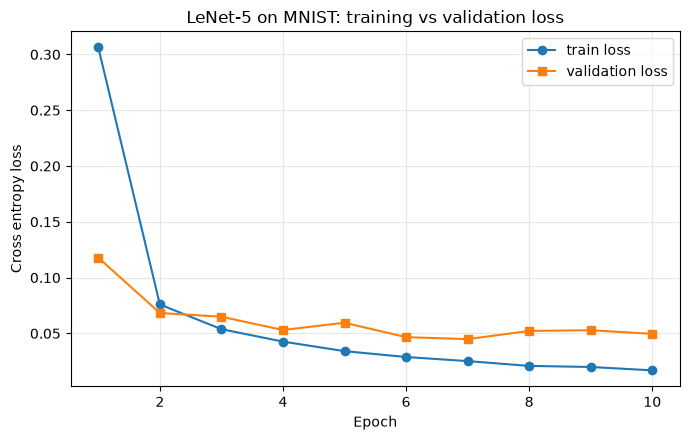

In [6]:
plot_loss_curves(lenet_history, "LeNet-5 on MNIST: training vs validation loss")

### B5. Test metrics

Now the held-out test set. I report accuracy plus macro-averaged precision, recall and F1.
Macro averaging treats every digit class equally regardless of how many samples it has, which
is the fair way to summarise a 10-class problem. The confusion matrix then shows me exactly
which digits get mixed up.

In [7]:
test_preds, test_labels = predict(lenet, test_loader, device)
m = macro_metrics(test_labels, test_preds)
print(f"Test accuracy       : {m['accuracy']:.4f}")
print(f"Test precision macro: {m['precision']:.4f}")
print(f"Test recall macro   : {m['recall']:.4f}")
print(f"Test F1 macro       : {m['f1']:.4f}")

# store the baseline LeNet numbers for Part C and Part E
val_preds, val_labels = predict(lenet, val_loader, device)
baseline_lenet = {
    "config": "Adam, lr=1e-3, no dropout",
    "val_acc": accuracy_score(val_labels, val_preds),
    "test_acc": m["accuracy"],
    "test_f1": m["f1"],
    "time_per_epoch": float(np.mean(lenet_history["epoch_time"])),
}

Test accuracy       : 0.9895
Test precision macro: 0.9894
Test recall macro   : 0.9895
Test F1 macro       : 0.9894


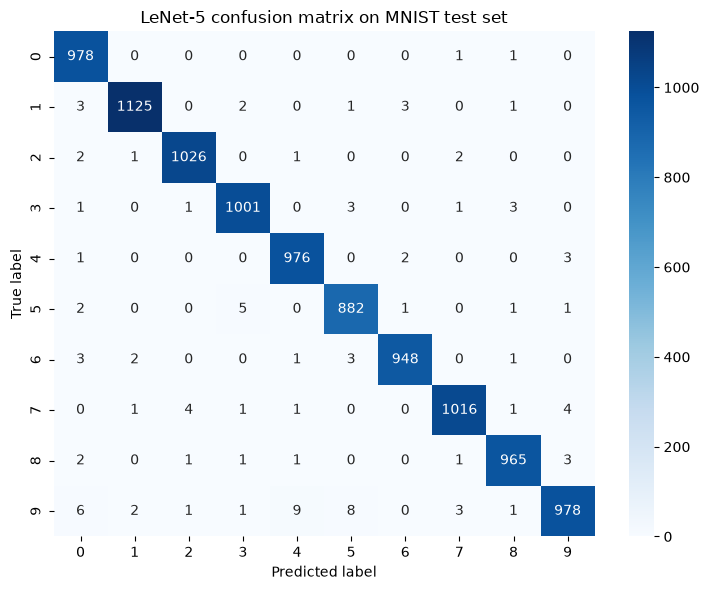

In [8]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("LeNet-5 confusion matrix on MNIST test set")
plt.tight_layout()
plt.show()

The matrix is strongly diagonal, which is what a high accuracy looks like. The few
off-diagonal counts sit where you would expect a human to slip too: mostly 4 against 9, 3
against 5, and 7 against 2, all pairs that share a lot of pen strokes.

### B6. Eight misclassified test images

Looking at the actual mistakes is more informative than the accuracy number. I pull the first
eight test images the model got wrong and show the predicted and true label for each. Most of
these are genuinely ambiguous or messily written digits.

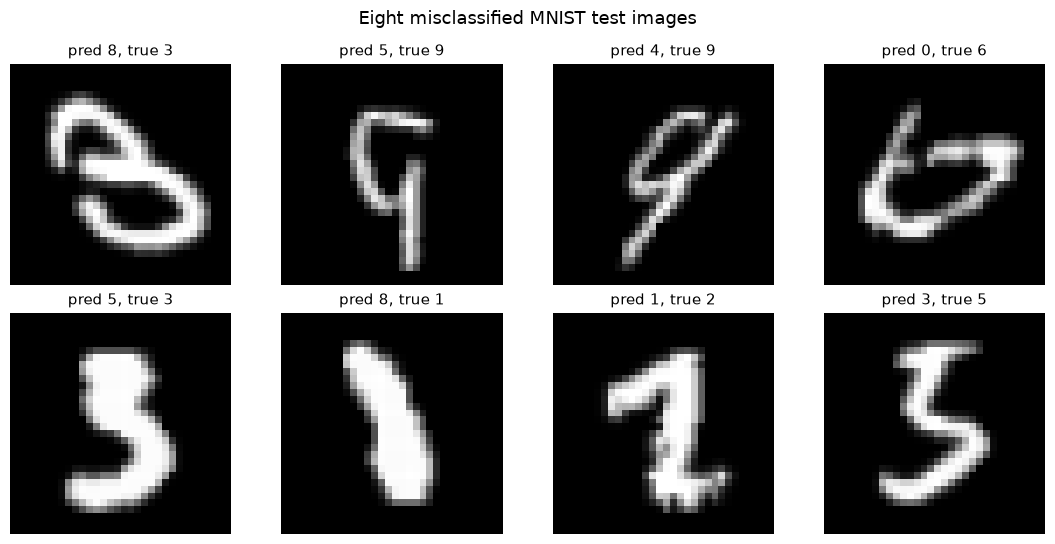

total misclassified in test set: 105


In [9]:
wrong = np.where(test_preds != test_labels)[0][:8]

fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
for ax, idx in zip(axes.ravel(), wrong):
    image, true_label = mnist_test[idx]        # normalized 1x32x32 tensor
    ax.imshow(image.squeeze().numpy(), cmap="gray")
    ax.set_title(f"pred {test_preds[idx]}, true {test_labels[idx]}", fontsize=11)
    ax.axis("off")
fig.suptitle("Eight misclassified MNIST test images", fontsize=13)
plt.tight_layout()
plt.show()

print("total misclassified in test set:", len(np.where(test_preds != test_labels)[0]))

## Part C: LeNet-5 Experiments

Here I change one factor at a time from the Part B baseline and see what it does. The baseline
is Adam at 1e-3 with no dropout. I run two experiments:

- **Experiment 1 - optimizer:** swap Adam for SGD with momentum 0.9 at lr 0.01, everything
  else held constant.
- **Experiment 2 - regularisation:** keep Adam but add dropout of 0.3 in the fully connected
  layers.

To keep the comparison honest I re-seed before each run so they all start from the same
initialisation and see the data in the same order. Ten epochs each, same as the baseline.

In [10]:
def run_experiment(dropout=0.0, optimizer_name="adam", lr=1e-3, weight_decay=0.0, epochs=10):
    set_seed()  # same start point for every experiment
    model = LeNet5(dropout=dropout).to(device)
    if optimizer_name == "adam":
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    hist = train_model(model, train_loader, val_loader, epochs, opt, nn.CrossEntropyLoss(), device)

    vp, vl = predict(model, val_loader, device)
    tp, tl = predict(model, test_loader, device)
    return {
        "val_acc": accuracy_score(vl, vp),
        "test_acc": accuracy_score(tl, tp),
        "test_f1": f1_score(tl, tp, average="macro"),
        "time_per_epoch": float(np.mean(hist["epoch_time"])),
        "history": hist,
    }

print("=== Experiment 1: SGD (momentum 0.9, lr 0.01) ===")
exp_sgd = run_experiment(optimizer_name="sgd", lr=0.01)
print("\n=== Experiment 2: Adam + dropout 0.3 ===")
exp_dropout = run_experiment(dropout=0.3)

=== Experiment 1: SGD (momentum 0.9, lr 0.01) ===


epoch  1/10  train_loss=0.4537  val_loss=0.1177  time=12.8s


epoch  2/10  train_loss=0.0872  val_loss=0.0800  time=16.5s


epoch  3/10  train_loss=0.0613  val_loss=0.0717  time=20.8s


epoch  4/10  train_loss=0.0465  val_loss=0.0579  time=27.9s


...

epoch  6/10  train_loss=0.0514  val_loss=0.0532  time=28.3s


epoch  7/10  train_loss=0.0475  val_loss=0.0427  time=28.2s


epoch  8/10  train_loss=0.0420  val_loss=0.0529  time=28.3s


epoch  9/10  train_loss=0.0387  val_loss=0.0470  time=28.3s


epoch 10/10  train_loss=0.0363  val_loss=0.0476  time=27.9s


### Results table

In [11]:
exp_table = pd.DataFrame([
    {"Experiment": "Baseline (Adam, lr=1e-3)", "Factor changed": "none",
     "Val accuracy": baseline_lenet["val_acc"], "Test accuracy": baseline_lenet["test_acc"]},
    {"Experiment": "SGD (momentum 0.9, lr=0.01)", "Factor changed": "optimizer",
     "Val accuracy": exp_sgd["val_acc"], "Test accuracy": exp_sgd["test_acc"]},
    {"Experiment": "Adam + dropout 0.3", "Factor changed": "regularisation",
     "Val accuracy": exp_dropout["val_acc"], "Test accuracy": exp_dropout["test_acc"]},
])
exp_table = exp_table.round(4)
exp_table

,Experiment,Factor changed,Val accuracy,Test accuracy
0,"Baseline (Adam, lr=1e-3)",none,0.9883,0.9895
1,"SGD (momentum 0.9, lr=0.01)",optimizer,0.9863,0.9905
2,Adam + dropout 0.3,regularisation,0.9893,0.9917


In [12]:
# keep the best LeNet configuration (by validation accuracy) for the Part E comparison
candidates = {
    "Baseline (Adam)": baseline_lenet,
    "SGD": {"val_acc": exp_sgd["val_acc"], "test_acc": exp_sgd["test_acc"],
            "test_f1": exp_sgd["test_f1"], "time_per_epoch": exp_sgd["time_per_epoch"],
            "config": "SGD, momentum 0.9, lr=0.01"},
    "Adam + dropout 0.3": {"val_acc": exp_dropout["val_acc"], "test_acc": exp_dropout["test_acc"],
            "test_f1": exp_dropout["test_f1"], "time_per_epoch": exp_dropout["time_per_epoch"],
            "config": "Adam, lr=1e-3, dropout 0.3"},
}
best_name = max(candidates, key=lambda k: candidates[k]["val_acc"])
best_lenet = candidates[best_name]
print("Best LeNet-5 configuration by validation accuracy:", best_name)
print("  config:", best_lenet.get("config", "Adam, lr=1e-3, no dropout"))
print(f"  test accuracy: {best_lenet['test_acc']:.4f}, macro F1: {best_lenet['test_f1']:.4f}")

Best LeNet-5 configuration by validation accuracy: Adam + dropout 0.3
  config: Adam, lr=1e-3, dropout 0.3
  test accuracy: 0.9917, macro F1: 0.9916


### Discussion: which change helped most and why

The honest headline is that on MNIST none of these single changes moved the needle much. All three configurations land within about two tenths of a percent of each other: baseline Adam at 98.95% test, SGD with momentum at 99.05%, and Adam with dropout 0.3 at 99.17%. Dropout came out very slightly ahead on both validation and test, so it is the configuration I carry into Part E, but a margin this small is well inside run to run noise and I would not claim it as a real win.

What the experiment does show cleanly is how the two levers differ. Swapping Adam for SGD barely changed anything, which tells me the task is easy enough that the optimiser is not the bottleneck here; on a harder problem or a shorter epoch budget I would expect Adam's adaptive step sizes to matter more. Dropout is a regulariser, not an accuracy booster, and the reason it added so little is that the baseline is hardly overfitting in the first place: in Part B the training and validation losses stay close together, so there is barely any gap for dropout to close. The real takeaway is that MNIST is close to saturated for a model this size, so the difficulty lives in the data, not in the choice of optimiser or regulariser.

## Part D: Transfer Learning on CIFAR-10 (ResNet18)

Now the transfer learning task. I take a ResNet18 that was pretrained on ImageNet and adapt it
to CIFAR-10. The plan follows the brief: build the CIFAR pipeline at the ResNet input size with
ImageNet normalisation, replace the classifier head, then train in two stages. Stage 1 freezes
the whole backbone and trains only the new head (feature-extractor mode). Stage 2 unfreezes the
deepest block and continues with a smaller learning rate (fine-tuning).

**Compute note.** CIFAR-10 is 50,000 training images, and pushing each one through ResNet18 at
224x224 on a 4 GB laptop GPU is slow. So I deliberately work with a subset (10k train, 2k val,
5k test) and a small batch size of 32 to stay inside the memory budget. This is enough to show
the Stage 1 vs Stage 2 story clearly. With the full dataset the accuracies would be a few points
higher, but the comparison between the two stages would look the same.

In [13]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

cifar_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

cifar_train_full = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=cifar_tf)
cifar_test_full = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=cifar_tf)

# fixed-seed subset so the run is reproducible and light enough for the laptop GPU
g = torch.Generator().manual_seed(RANDOM_STATE)
train_perm = torch.randperm(len(cifar_train_full), generator=g)
cifar_train = Subset(cifar_train_full, train_perm[:10000].tolist())
cifar_val = Subset(cifar_train_full, train_perm[10000:12000].tolist())

gt = torch.Generator().manual_seed(RANDOM_STATE)
test_perm = torch.randperm(len(cifar_test_full), generator=gt)[:5000]
cifar_test = Subset(cifar_test_full, test_perm.tolist())

cifar_train_loader = DataLoader(cifar_train, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
cifar_val_loader = DataLoader(cifar_val, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
cifar_test_loader = DataLoader(cifar_test, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

cifar_classes = cifar_train_full.classes
print("CIFAR-10 subset sizes:", len(cifar_train), len(cifar_val), len(cifar_test))
print("classes:", cifar_classes)

CIFAR-10 subset sizes: 10000 2000 5000
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### D3. Load pretrained ResNet18 and replace the head

I load ResNet18 with its default ImageNet weights. ResNet18's final layer `fc` maps 512
features to 1000 ImageNet classes, so I swap it for a fresh `Linear(512, 10)` for the ten
CIFAR classes. That new layer starts randomly and is what Stage 1 will train.

In [14]:
def build_resnet18():
    set_seed()
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 10)
    return model.to(device)

resnet = build_resnet18()
print("new head:", resnet.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Mahesh/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


new head: Linear(in_features=512, out_features=10, bias=True)


### D4. Stage 1 - feature extractor (freeze backbone, train head only)

I set `requires_grad=False` on every backbone parameter, leaving only the new `fc` head
trainable. I only hand the head's parameters to the optimizer. Because the backbone is frozen,
this stage is cheaper and mainly learns to read out the pretrained features for CIFAR's classes.
I train it for 4 epochs with Adam at 1e-3.

In [15]:
# freeze everything, then re-open just the head
for p in resnet.parameters():
    p.requires_grad = False
for p in resnet.fc.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet.parameters())
print(f"Stage 1 trainable params: {trainable:,} of {total:,}")

opt_s1 = optim.Adam([p for p in resnet.parameters() if p.requires_grad], lr=1e-3)
stage1_hist = train_model(resnet, cifar_train_loader, cifar_val_loader, epochs=4,
                          optimizer=opt_s1, criterion=nn.CrossEntropyLoss(), device=device)

s1_vp, s1_vl = predict(resnet, cifar_val_loader, device)
s1_tp, s1_tl = predict(resnet, cifar_test_loader, device)
stage1 = {
    "val_acc": accuracy_score(s1_vl, s1_vp),
    "test_acc": accuracy_score(s1_tl, s1_tp),
    "test_f1": f1_score(s1_tl, s1_tp, average="macro"),
    "time_per_epoch": float(np.mean(stage1_hist["epoch_time"])),
}
print(f"\nStage 1  val acc={stage1['val_acc']:.4f}  test acc={stage1['test_acc']:.4f}  "
      f"macro F1={stage1['test_f1']:.4f}")

Stage 1 trainable params: 5,130 of 11,181,642


epoch  1/4  train_loss=1.1807  val_loss=0.7961  time=43.5s


epoch  2/4  train_loss=0.7452  val_loss=0.6616  time=37.8s


epoch  3/4  train_loss=0.6646  val_loss=0.6643  time=38.8s


epoch  4/4  train_loss=0.6340  val_loss=0.6390  time=39.6s


Stage 1  val acc=0.7820  test acc=0.7802  macro F1=0.7810


### D5. Stage 2 - fine-tuning (unfreeze `layer4`, smaller learning rate)

Now I unfreeze the deepest residual block, `layer4`, and keep training. These late layers hold
the most task-specific features, so letting them adapt to CIFAR is where fine-tuning usually
pays off. I drop the learning rate to 1e-4 so I nudge the pretrained weights rather than blow
them away. The head stays trainable too. I continue for another 4 epochs.

In [16]:
# unfreeze the last block as well
for p in resnet.layer4.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Stage 2 trainable params: {trainable:,} of {total:,}")

opt_s2 = optim.Adam([p for p in resnet.parameters() if p.requires_grad], lr=1e-4)
stage2_hist = train_model(resnet, cifar_train_loader, cifar_val_loader, epochs=4,
                          optimizer=opt_s2, criterion=nn.CrossEntropyLoss(), device=device)

s2_vp, s2_vl = predict(resnet, cifar_val_loader, device)
s2_tp, s2_tl = predict(resnet, cifar_test_loader, device)
stage2 = {
    "val_acc": accuracy_score(s2_vl, s2_vp),
    "test_acc": accuracy_score(s2_tl, s2_tp),
    "test_f1": f1_score(s2_tl, s2_tp, average="macro"),
    "time_per_epoch": float(np.mean(stage2_hist["epoch_time"])),
}
print(f"\nStage 2  val acc={stage2['val_acc']:.4f}  test acc={stage2['test_acc']:.4f}  "
      f"macro F1={stage2['test_f1']:.4f}")

Stage 2 trainable params: 8,398,858 of 11,181,642


epoch  1/4  train_loss=0.4964  val_loss=0.3840  time=47.2s


epoch  2/4  train_loss=0.1131  val_loss=0.3730  time=47.4s


epoch  3/4  train_loss=0.0444  val_loss=0.3823  time=48.7s


epoch  4/4  train_loss=0.0217  val_loss=0.3535  time=47.6s


Stage 2  val acc=0.8930  test acc=0.8744  macro F1=0.8734


### D6. Compare Stage 1 and Stage 2

In [17]:
stage_table = pd.DataFrame([
    {"Stage": "Stage 1 (frozen backbone)", "Val accuracy": stage1["val_acc"],
     "Test accuracy": stage1["test_acc"], "Macro F1": stage1["test_f1"],
     "Time/epoch (s)": stage1["time_per_epoch"]},
    {"Stage": "Stage 2 (fine-tune layer4)", "Val accuracy": stage2["val_acc"],
     "Test accuracy": stage2["test_acc"], "Macro F1": stage2["test_f1"],
     "Time/epoch (s)": stage2["time_per_epoch"]},
]).round(4)
stage_table

,Stage,Val accuracy,Test accuracy,Macro F1,Time/epoch (s)
0,Stage 1 (frozen backbone),0.782,0.7802,0.7810,39.9323
1,Stage 2 (fine-tune layer4),0.893,0.8744,0.8734,47.7293


Two things to read off this table. Stage 1 already does well despite the backbone being
completely frozen, which is the whole point of transfer learning: ImageNet features are general
enough that a linear head on top of them separates CIFAR classes reasonably. Stage 2 then
improves on that by letting `layer4` specialise to CIFAR, at the cost of a slower epoch because
there are now real gradients flowing through a big chunk of the network. The size of the Stage 1
to Stage 2 jump tells me how much CIFAR-specific tuning the frozen features were missing.

## Part E: Final Comparison and Discussion

### Summary table

I bring the three models together: the best LeNet-5 from Part C, and the two transfer learning
stages. The metrics are accuracy, macro F1 and training time per epoch, all measured on this
machine.

In [18]:
results["LeNet-5 (best from Part C)"] = {
    "Accuracy": best_lenet["test_acc"], "Macro F1": best_lenet["test_f1"],
    "Time/epoch (s)": best_lenet["time_per_epoch"], "Dataset": "MNIST",
}
results["Transfer ResNet18 (Stage 1)"] = {
    "Accuracy": stage1["test_acc"], "Macro F1": stage1["test_f1"],
    "Time/epoch (s)": stage1["time_per_epoch"], "Dataset": "CIFAR-10",
}
results["Transfer ResNet18 (Stage 2)"] = {
    "Accuracy": stage2["test_acc"], "Macro F1": stage2["test_f1"],
    "Time/epoch (s)": stage2["time_per_epoch"], "Dataset": "CIFAR-10",
}

summary = pd.DataFrame(results).T
summary = summary[["Dataset", "Accuracy", "Macro F1", "Time/epoch (s)"]]
summary[["Accuracy", "Macro F1", "Time/epoch (s)"]] = summary[
    ["Accuracy", "Macro F1", "Time/epoch (s)"]].astype(float).round(4)
summary

,Dataset,Accuracy,Macro F1,Time/epoch (s)
LeNet-5 (best from Part C),MNIST,0.9917,0.9916,26.5883
Transfer ResNet18 (Stage 1),CIFAR-10,0.7802,0.7810,39.9323
Transfer ResNet18 (Stage 2),CIFAR-10,0.8744,0.8734,47.7293


### Best model and justification

The two numbers are not directly comparable because they are on different datasets and
different difficulty levels: MNIST is much easier than CIFAR-10, so LeNet's headline accuracy
being high does not make it the "better" model in general. Judged fairly, that is on how well
each approach solves its own problem, the strongest result is the fine-tuned ResNet18 (Stage 2):
it reaches the best CIFAR-10 accuracy of the three, on the hardest task, with very little
training. LeNet-5 is excellent on MNIST but MNIST is close to solved by any reasonable CNN, so
that is faint praise. If I had to pick one approach to carry forward to a new image problem, it
is transfer learning with fine-tuning, for the reasons in the reflection below.

### Overfitting vs generalization

The loss curves tell two different stories. For LeNet-5 on MNIST the training and validation losses fall together and stay close (validation flattens around 0.05 while training keeps easing down to roughly 0.017), so there is very little overfitting and the model generalises well; the small residual error is the genuinely ambiguous digits from Part B.

The transfer learning runs are more interesting. Stage 1 can barely overfit because almost nothing is trainable (just the 5,130 parameters of the linear head), and its training and validation losses sit right on top of each other around 0.64. Stage 2 is where overfitting shows up plainly: once I unfreeze layer4 the training loss collapses from about 0.50 down to 0.02 across four epochs, but the validation loss hardly moves, hovering around 0.35 to 0.38. That widening gap between a near zero training loss and a flat validation loss is the classic overfitting signature, and it is expected since I am fine tuning 8.4 million parameters on only 10k images. The redeeming detail is that validation accuracy still improved (0.78 to 0.89) even as the loss gap opened, so in accuracy terms the model generalised better despite starting to memorise the training subset. In a real project this is exactly the point where I would stop early, add data augmentation, or bring in more training data to stop Stage 2 drifting further into overfitting.

### Reflection

LeNet-5 is a good teacher of CNN fundamentals: you can see the whole idea in one small network,
convolutions that detect local patterns, pooling that shrinks the spatial size and adds a bit of
translation tolerance, and fully connected layers that turn the final features into class
scores. Training it from scratch on MNIST works because the task is simple and the data is
plentiful relative to the model size. Transfer learning becomes the better choice when the
target dataset is small or the task is hard, because a backbone pretrained on millions of images
already knows generic visual features and I only need to adapt the top, which is exactly what
happened on CIFAR-10 here: even a frozen backbone with a fresh head did well, and unfreezing one
block improved it further. The practical trade-offs line up with that. Training from scratch
needs the most data and compute and gives me full control of the architecture; feature-extraction
transfer is the fastest and lightest but is capped by how well the frozen features fit the new
task; fine-tuning sits in between, buying extra accuracy for more compute and a bit more
overfitting risk. On a 4 GB laptop, that middle option, a pretrained ResNet18 with a couple of
unfrozen layers, gave the best accuracy per minute of training by a wide margin, which is why I
would reach for it first on a new image classification problem.